**Upload and load the dataset**

**First 5 rows and last 5 rows**

**Check info, missing values, duplicates**

**Fill missing values**

**Handle outliers using IQR**

**Feature engineering (Risk_Score)**
**Scale numeric features**

**Plot target distribution, numeric feature histograms, correlation heatmap**

Saving archive (3).zip to archive (3) (1).zip
Dataset Loaded Successfully

Dataset Shape (rows, columns): (48536, 21)

First 5 Rows:
                              Patient_ID  Age     Sex Family_History  \
0  b2a49170-8561-4665-9371-2240b55dd87a   31    Male             No   
1  f5fae45d-8718-41c4-a957-6928f79f3c8e   33  Female            Yes   
2  66ab0567-050b-4d56-9ec4-b676309899a6   69    Male            Yes   
3  996a48e4-e841-418f-a539-5a7a86cd815d   66    Male            Yes   
4  d45c7ca8-7125-4aaa-8018-5bbc60d35a1f   43  Female            Yes   

   HTT_CAG_Repeat_Length Motor_Symptoms Cognitive_Decline  Chorea_Score  \
0                     67       Moderate            Severe          8.80   
1                     38         Severe          Moderate          3.24   
2                     37         Severe          Moderate          1.01   
3                     50           Mild            Severe          3.21   
4                     48       Moderate              Mild       

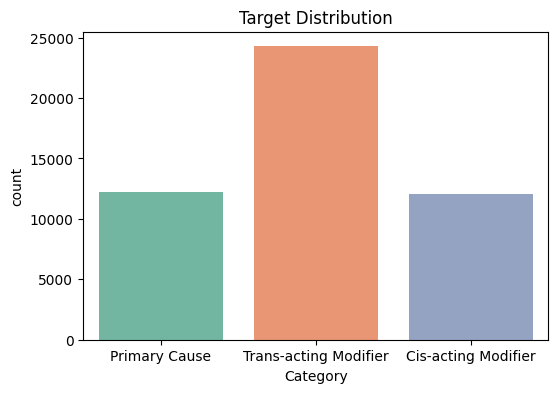

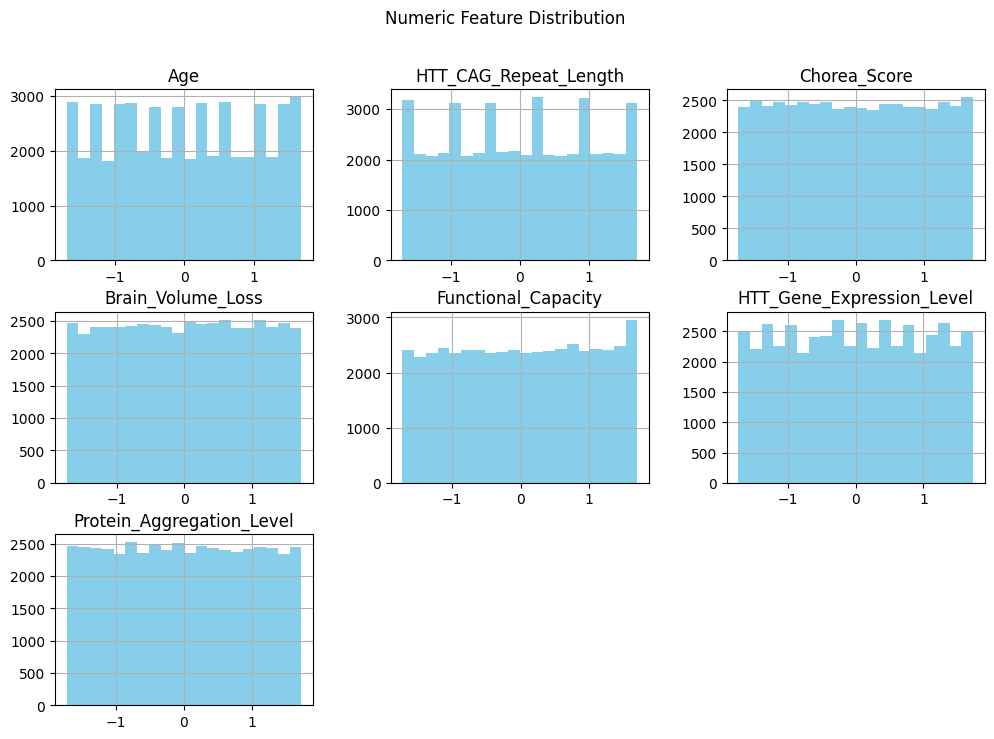

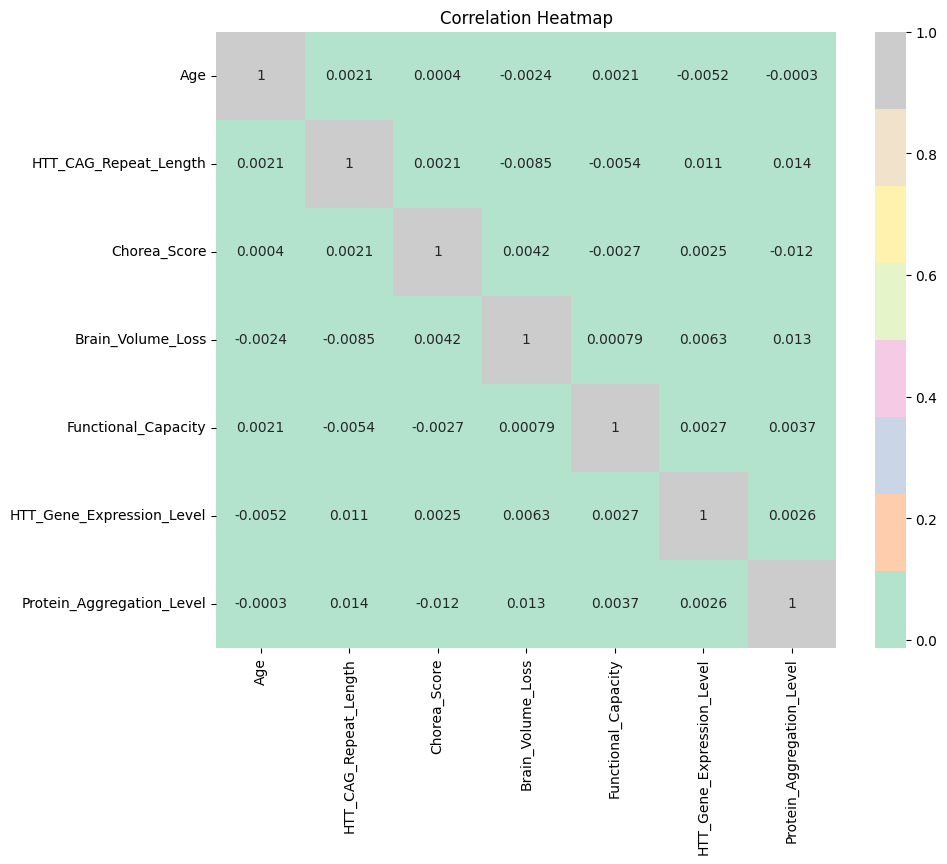


Cleaned Dataset First 5 Rows:
                              Patient_ID       Age     Sex Family_History  \
0  b2a49170-8561-4665-9371-2240b55dd87a -1.630576    Male             No   
1  f5fae45d-8718-41c4-a957-6928f79f3c8e -1.495093  Female            Yes   
2  66ab0567-050b-4d56-9ec4-b676309899a6  0.943601    Male            Yes   
3  996a48e4-e841-418f-a539-5a7a86cd815d  0.740376    Male            Yes   
4  d45c7ca8-7125-4aaa-8018-5bbc60d35a1f -0.817678  Female            Yes   

   HTT_CAG_Repeat_Length Motor_Symptoms Cognitive_Decline  Chorea_Score  \
0               0.714972       Moderate            Severe      1.313501   
1              -1.471395         Severe          Moderate     -0.605530   
2              -1.546787         Severe          Moderate     -1.375213   
3              -0.566692           Mild            Severe     -0.615884   
4              -0.717475       Moderate              Mild     -0.926519   

   Brain_Volume_Loss  Functional_Capacity  ... HTT_Gene_Expr

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from google.colab import files
import zipfile
import os
import warnings
warnings.filterwarnings('ignore')

# Upload ZIP file containing the dataset
uploaded = files.upload()
zip_filename = list(uploaded.keys())[0]

# Extract the ZIP file
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall("/content/")

# Load CSV file
csv_file = [f for f in os.listdir("/content/") if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join("/content/", csv_file))
print("Dataset Loaded Successfully\n")

# Show basic dataset information
print("Dataset Shape (rows, columns):", df.shape)
print("\nFirst 5 Rows:\n", df.head())
print("\nLast 5 Rows:\n", df.tail())
print("\nColumns and Data Types:\n", df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

# Drop duplicates
df.drop_duplicates(inplace=True)

# Preprocess numeric columns
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Fill missing values
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Handle outliers using IQR
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

# Feature engineering
if 'Age' in df.columns and 'CAG_repeats' in df.columns:
    df['Risk_Score'] = df['Age'] * df['CAG_repeats']

# Scale numeric columns
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Simple EDA plots
target_column = 'Status' if 'Status' in df.columns else df.columns[-1]

# Target distribution
plt.figure(figsize=(6,4))
sns.countplot(x=target_column, data=df, palette='Set2')
plt.title('Target Distribution')
plt.show()

# Histograms for numeric columns
df[numeric_cols].hist(figsize=(12,8), bins=20, color='skyblue')
plt.suptitle('Numeric Feature Distribution')
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='Pastel2')
plt.title('Correlation Heatmap')
plt.show()

# Final cleaned dataset sample
print("\nCleaned Dataset First 5 Rows:\n", df.head())
print("\nCleaned Dataset Last 5 Rows:\n", df.tail())
